<a href="https://colab.research.google.com/github/helloabser/property-price-estimator/blob/main/property-price-estimator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install & Import Libraries

In [ ]:
# Install required libraries
!pip install -q scikit-learn seaborn joblib


In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from pathlib import Path

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

Libraries imported successfully!


Load Dataset

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Understand Dataset

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Rows: 20640
Columns: 9

Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


Data Dictionary

In [7]:
## Data Dictionary

| Feature | Description |
|---|---|
| MedInc | Median income in the block group |
| HouseAge | Median house age |
| AveRooms | Average number of rooms |
| AveBedrms | Average number of bedrooms |
| Population | Block group population |
| AveOccup | Average household occupancy |
| Latitude | Geographic latitude |
| Longitude | Geographic longitude |
| MedHouseVal | Median house value — Target |

SyntaxError: invalid character '—' (U+2014) (3391938273.py, line 13)

In [8]:
print("Missing values per column:")
display(df.isnull().sum())

Missing values per column:


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


Data Quality Check

In [9]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().mean() * 100).round(2)
})

display(missing)

,Missing Values,Missing %
MedInc,0,0.0
HouseAge,0,0.0
AveRooms,0,0.0
AveBedrms,0,0.0
Population,0,0.0
AveOccup,0,0.0
Latitude,0,0.0
Longitude,0,0.0
MedHouseVal,0,0.0


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
display(df.nunique().to_frame("Unique Values"))

,Unique Values
MedInc,12928
HouseAge,52
AveRooms,19392
AveBedrms,14233
Population,3888
AveOccup,18841
Latitude,862
Longitude,844
MedHouseVal,3842


Separate X and y

In [12]:
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 8)
y shape: (20640,)


Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (16512, 8)
Testing data : (4128, 8)


Exploratory Data Analysis

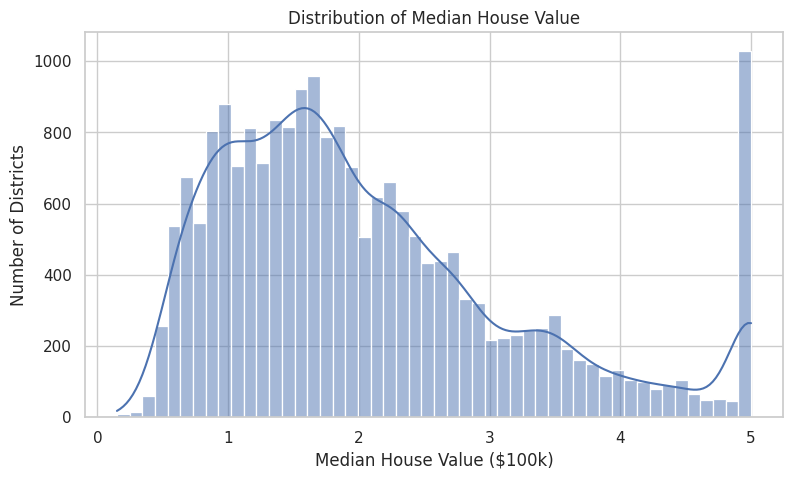

In [14]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["MedHouseVal"],
    bins=50,
    kde=True
)

plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value ($100k)")
plt.ylabel("Number of Districts")

plt.show()

Correlation with Target

In [15]:
correlation = df.corr(numeric_only=True)["MedHouseVal"]

correlation = correlation.sort_values(ascending=False)

display(correlation.to_frame("Correlation"))

,Correlation
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


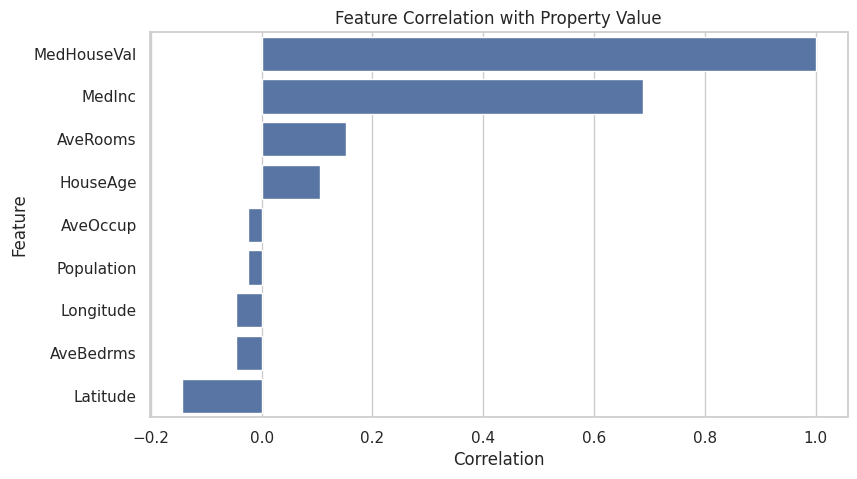

In [16]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=correlation.values,
    y=correlation.index
)

plt.title("Feature Correlation with Property Value")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

Income vs Property Price

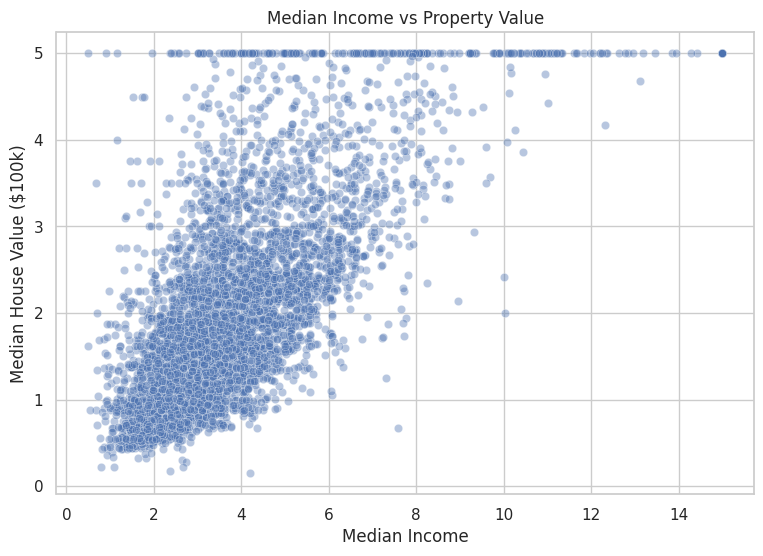

In [17]:
sample_df = df.sample(
    5000,
    random_state=RANDOM_STATE
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=sample_df,
    x="MedInc",
    y="MedHouseVal",
    alpha=0.4
)

plt.title("Median Income vs Property Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value ($100k)")

plt.show()

House Age vs Price

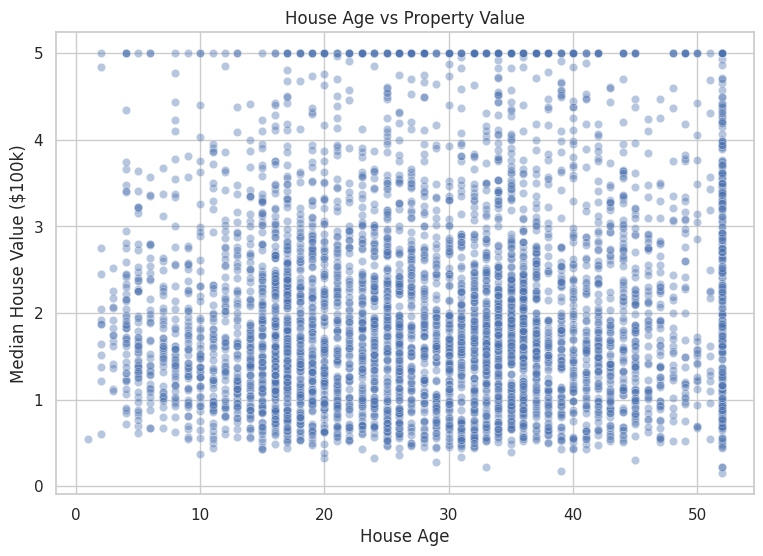

In [18]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=sample_df,
    x="HouseAge",
    y="MedHouseVal",
    alpha=0.4
)

plt.title("House Age vs Property Value")
plt.xlabel("House Age")
plt.ylabel("Median House Value ($100k)")

plt.show()

Population vs Price

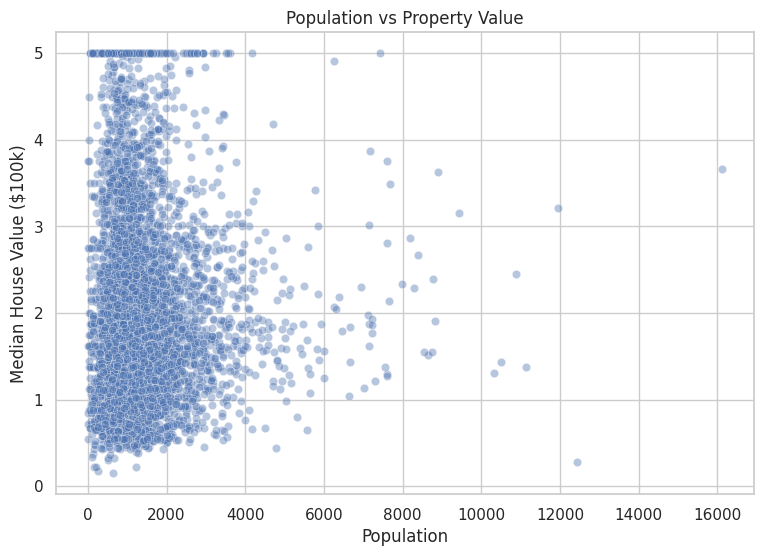

In [19]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=sample_df,
    x="Population",
    y="MedHouseVal",
    alpha=0.4
)

plt.title("Population vs Property Value")
plt.xlabel("Population")
plt.ylabel("Median House Value ($100k)")

plt.show()

Geographic Distribution

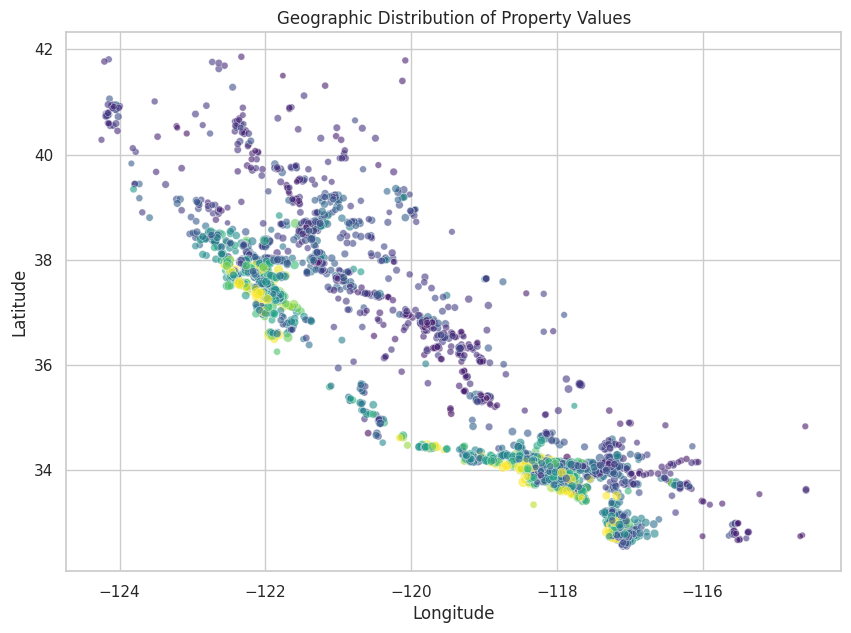

In [20]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=sample_df,
    x="Longitude",
    y="Latitude",
    hue="MedHouseVal",
    size="MedInc",
    alpha=0.6,
    palette="viridis",
    legend=False
)

plt.title("Geographic Distribution of Property Values")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

Correlation Heatmap

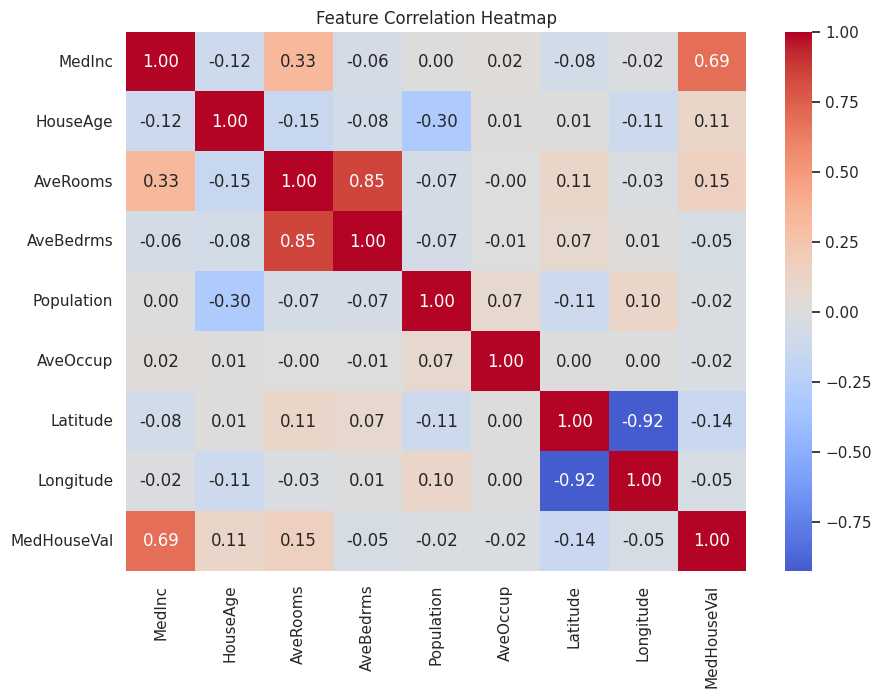

In [21]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

Baseline Model

In [22]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [23]:
linear_pred = linear_model.predict(X_test)

print(linear_pred[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


Evaluate Linear Regression

In [24]:
linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = mean_squared_error(
    y_test,
    linear_pred
) ** 0.5

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("Linear Regression Results")
print("-------------------------")

print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²  :", round(linear_r2, 4))

Linear Regression Results
-------------------------
MAE : 0.5332
RMSE: 0.7456
R²  : 0.5758


Random Forest Model

In [25]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


Random Forest Prediction

In [26]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:10])

[0.49589678 0.74525252 4.87822082 2.54044802 2.28862841 1.63494219
 2.39889318 1.65483007 2.61983005 4.89729427]


Random Forest Evaluation

In [27]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = mean_squared_error(
    y_test,
    rf_pred
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest Results")
print("---------------------")

print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²  :", round(rf_r2, 4))

Random Forest Results
---------------------
MAE : 0.3263
RMSE: 0.504
R²  : 0.8062


Model Comparison

In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],

    "MAE": [
        linear_mae,
        rf_mae
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse
    ],

    "R2": [
        linear_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.533200,0.745581,0.575788
1,Random Forest,0.326281,0.503955,0.806190


In [29]:
comparison.style.format({
    "MAE": "{:.4f}",
    "RMSE": "{:.4f}",
    "R2": "{:.4f}"
})

,Model,MAE,RMSE,R2
0,Linear Regression,0.5332,0.7456,0.5758
1,Random Forest,0.3263,0.5040,0.8062


Compare Models Visually

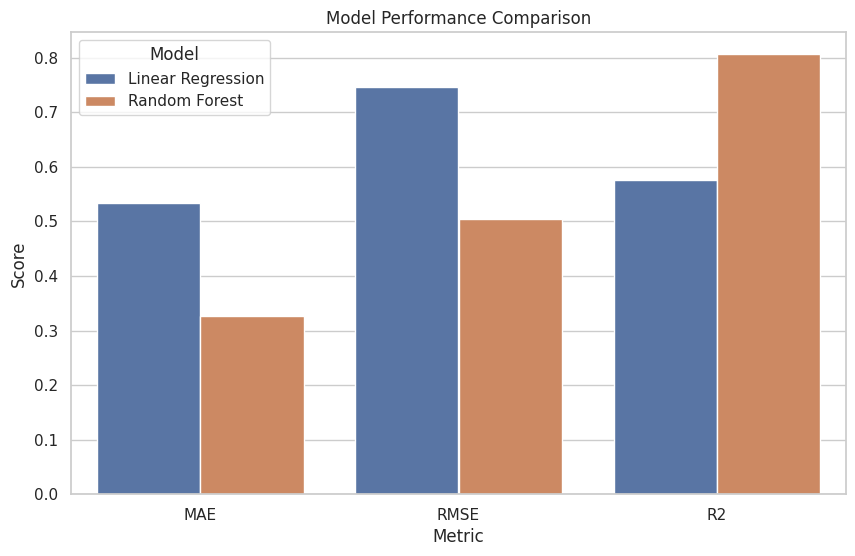

In [30]:
comparison_melted = comparison.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE", "R2"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Model Performance Comparison")

plt.show()

Actual vs Predicted

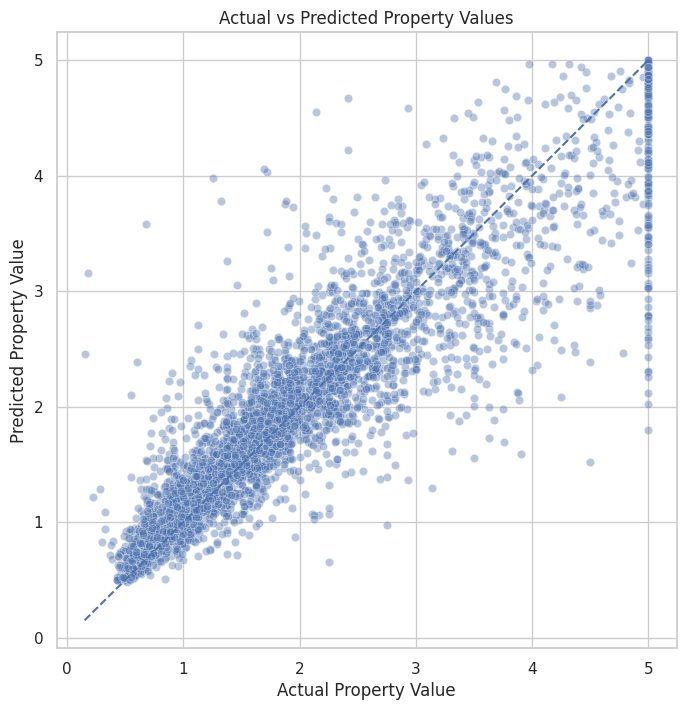

In [31]:
plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=y_test,
    y=rf_pred,
    alpha=0.4
)

min_value = min(
    y_test.min(),
    rf_pred.min()
)

max_value = max(
    y_test.max(),
    rf_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Property Value")
plt.ylabel("Predicted Property Value")

plt.title("Actual vs Predicted Property Values")

plt.show()

Residual Analysis

In [32]:
residuals = y_test - rf_pred

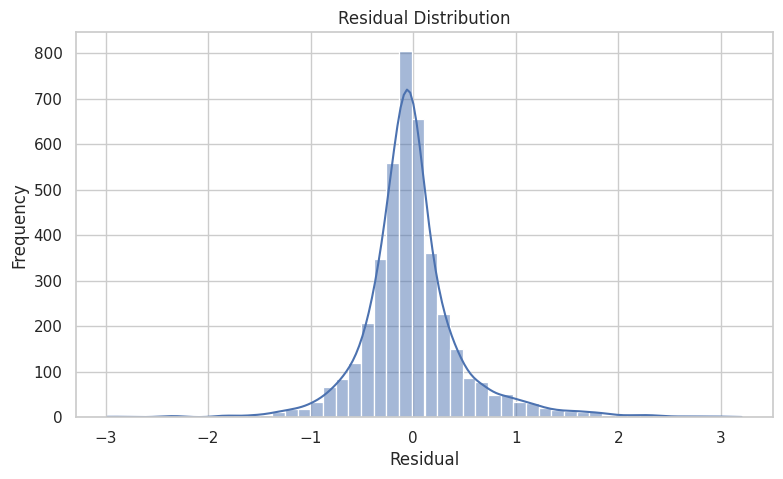

In [33]:
plt.figure(figsize=(9, 5))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

Residual vs Predicted

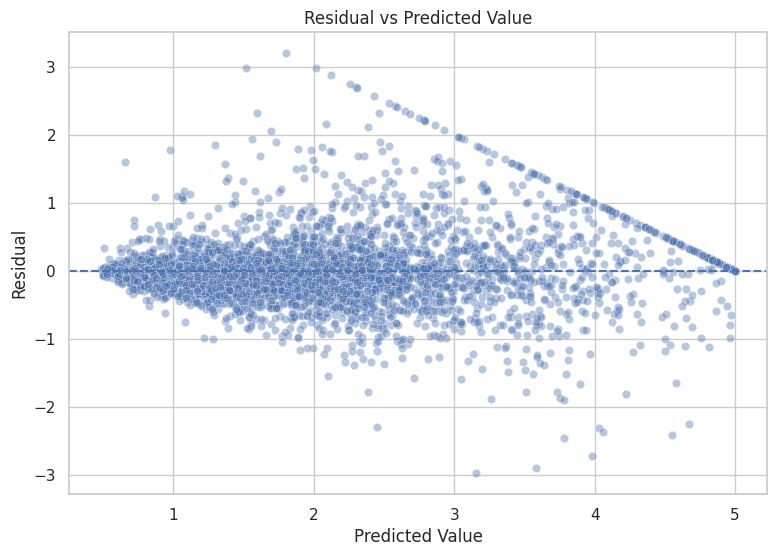

In [34]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=rf_pred,
    y=residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Value")
plt.ylabel("Residual")

plt.title("Residual vs Predicted Value")

plt.show()

Largest Prediction Errors

In [35]:
error_df = X_test.copy()

error_df["Actual"] = y_test.values

error_df["Predicted"] = rf_pred

error_df["Absolute_Error"] = abs(
    error_df["Actual"] -
    error_df["Predicted"]
)

largest_errors = error_df.sort_values(
    "Absolute_Error",
    ascending=False
)

display(
    largest_errors.head(10)
)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Actual,Predicted,Absolute_Error
12069,4.2386,6.0,7.723077,1.169231,228.0,3.507692,33.83,-117.55,5.00001,1.798656,3.201354
19542,1.7679,39.0,5.000000,0.888889,22.0,2.444444,37.63,-120.92,4.50000,1.516797,2.983203
6688,0.4999,28.0,7.677419,1.870968,142.0,4.580645,34.15,-118.08,5.00001,2.018604,2.981406
5887,2.3667,39.0,3.572464,1.217391,259.0,1.876812,34.15,-118.33,0.17500,3.156070,2.981070
4548,7.5752,52.0,3.142857,1.000000,55.0,7.857143,34.02,-118.21,0.67500,3.582577,2.907577
12389,3.7727,24.0,10.953586,1.848101,473.0,1.995781,33.75,-116.43,5.00001,2.119175,2.880835
12220,5.2066,4.0,10.500000,1.445652,311.0,3.380435,33.51,-117.32,5.00001,2.256835,2.743175
20349,7.3004,32.0,5.724138,0.758621,63.0,2.172414,34.17,-119.08,1.25000,3.980039,2.730039
17306,2.7275,17.0,5.574286,1.051429,681.0,1.945714,34.38,-119.55,5.00001,2.300064,2.699946
10574,1.9659,6.0,4.795455,1.159091,125.0,2.840909,33.72,-117.70,5.00001,2.309338,2.690672


Feature Importance

In [36]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

display(
    feature_importance.to_frame(
        "Importance"
    )
)

,Importance
MedInc,0.535389
AveOccup,0.138009
Latitude,0.088208
Longitude,0.088072
HouseAge,0.053245
AveRooms,0.042544
Population,0.027883
AveBedrms,0.026650


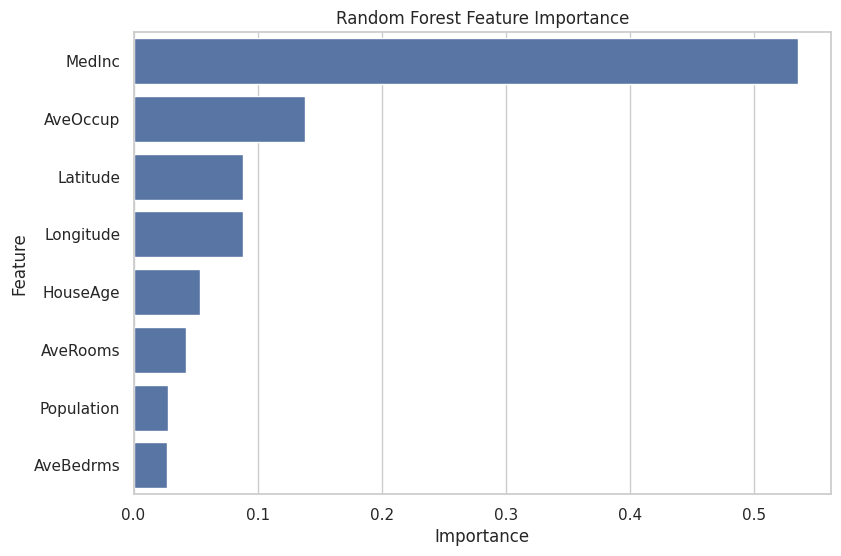

In [37]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Select Final Model

In [38]:
if rf_rmse < linear_rmse:
    final_model = rf_model
    final_model_name = "Random Forest"
else:
    final_model = linear_model
    final_model_name = "Linear Regression"

print("Final Model:", final_model_name)

Final Model: Random Forest


Save Model

In [39]:
from pathlib import Path

model_dir = Path("/content/models")

model_dir.mkdir(
    exist_ok=True
)

model_path = model_dir / "property_price_model.joblib"

joblib.dump(
    final_model,
    model_path
)

print("Model saved successfully!")
print(model_path)

Model saved successfully!
/content/models/property_price_model.joblib


Save Metrics

In [40]:
metrics = {
    "selected_model": final_model_name,

    "linear_regression": {
        "MAE": float(linear_mae),
        "RMSE": float(linear_rmse),
        "R2": float(linear_r2)
    },

    "random_forest": {
        "MAE": float(rf_mae),
        "RMSE": float(rf_rmse),
        "R2": float(rf_r2)
    }
}

metrics

{'selected_model': 'Random Forest',
 'linear_regression': {'MAE': 0.5332001304956553,
  'RMSE': 0.7455813830127764,
  'R2': 0.5757877060324508},
 'random_forest': {'MAE': 0.3262806348881271,
  'RMSE': 0.5039545719150003,
  'R2': 0.8061901171533774}}

In [41]:
with open(
    "/content/models/metrics.json",
    "w"
) as file:

    json.dump(
        metrics,
        file,
        indent=4
    )

print("Metrics saved!")

Metrics saved!


Test a New Property

In [42]:
new_property = pd.DataFrame({
    "MedInc": [5.0],
    "HouseAge": [20.0],
    "AveRooms": [6.0],
    "AveBedrms": [1.2],
    "Population": [1200],
    "AveOccup": [3.0],
    "Latitude": [34.0],
    "Longitude": [-118.0]
})

display(new_property)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,5.0,20.0,6.0,1.2,1200,3.0,34.0,-118.0


In [43]:
prediction = final_model.predict(
    new_property
)[0]

print(
    f"Estimated Property Value: ${prediction * 100000:,.0f}"
)

Estimated Property Value: $237,836
